# Customer Churn Prediction - Decision Tree Model

## Member 2: Decision Tree & Evaluation Framework

### Objective
Develop and evaluate a Decision Tree classifier to predict whether a customer is likely to churn.

### Responsibilities
- Build an initial Decision Tree model
- Evaluate performance using cross-validation
- Analyze overfitting and generalization
- Tune Decision Tree hyperparameters
- Compare untuned and tuned models
- Create reusable evaluation functions

### Shared Group 4 Protocol
- Dataset: Group 3 feature engineered customer churn dataset
- Target: Churn Value
- Split: 80% training / 20% testing
- Random State: 42
- Cross Validation: 5-fold StratifiedKFold
- Metrics:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - ROC-AUC

**Branch:** member2-ml-decision-tree

In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

# Pipeline and preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Save model
import joblib

import warnings
warnings.filterwarnings("ignore")


# Reproducibility
RANDOM_STATE = 42

In [5]:
# Dataset path

DATA_PATH = "../../Feature Engineering & Statistical Analysis/outputs/customer_churn_feature_engineered.csv"

data = pd.read_csv(DATA_PATH)

data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Churn Value,Is_New_Customer,Tenure_Band,Is_Month_to_Month,High_Monthly_Charge,Fiber_Monthly_Risk,New_High_Spend,New_Monthly_Customer,Support_Service_Count,Security_Tech_Bundle
0,Male,0,0,0,2,1,0,DSL,1,1,...,1,1,0-6,1,0,0,0,1,2,0
1,Female,0,0,1,2,1,0,Fiber optic,0,0,...,1,1,0-6,1,1,1,1,1,0,0
2,Female,0,0,1,8,1,1,Fiber optic,0,0,...,1,1,7-12,1,1,1,1,1,1,0
3,Female,0,1,1,28,1,1,Fiber optic,0,0,...,1,0,25-48,1,1,1,0,0,2,0
4,Male,0,0,1,49,1,1,Fiber optic,0,1,...,1,0,49+,1,1,1,0,0,2,0


In [6]:
print("Dataset Shape:")
print(data.shape)

print("\nColumns:")
print(data.columns.tolist())

print("\nMissing Values:")
print(data.isnull().sum().sum())

print("\nTarget Distribution:")
print(data["Churn Value"].value_counts())

Dataset Shape:
(7043, 29)

Columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Is_New_Customer', 'Tenure_Band', 'Is_Month_to_Month', 'High_Monthly_Charge', 'Fiber_Monthly_Risk', 'New_High_Spend', 'New_Monthly_Customer', 'Support_Service_Count', 'Security_Tech_Bundle']

Missing Values:
0

Target Distribution:
Churn Value
0    5174
1    1869
Name: count, dtype: int64


In [7]:
# Define Group 3 recommended core features

FEATURES = [
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "Fiber_Monthly_Risk",
    "New_High_Spend",
    "New_Monthly_Customer",
    "Security_Tech_Bundle"
]


TARGET = "Churn Value"


X = data[FEATURES]
y = data[TARGET]


print("Feature Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

print("\nFeatures Used:")
print(X.columns.tolist())

Feature Shape:
(7043, 21)

Target Shape:
(7043,)

Features Used:
['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Fiber_Monthly_Risk', 'New_High_Spend', 'New_Monthly_Customer', 'Security_Tech_Bundle']


In [8]:
# Train-test split using Group 4 protocol

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)


print("Training Data:")
print(X_train.shape)

print("\nTesting Data:")
print(X_test.shape)


print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True))


print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True))

Training Data:
(5634, 21)

Testing Data:
(1409, 21)

Training Target Distribution:
Churn Value
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing Target Distribution:
Churn Value
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [9]:
# Stratified 5-Fold Cross Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [10]:
# Identify categorical and numerical columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()


numerical_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()


print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Internet Service', 'Contract']

Numerical Features:
['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Fiber_Monthly_Risk', 'New_High_Spend', 'New_Monthly_Customer', 'Security_Tech_Bundle']


In [11]:
# Preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)


print("Preprocessor created successfully")

Preprocessor created successfully


In [12]:
# Initial Decision Tree (Untuned)

decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)


print("Initial Decision Tree pipeline created successfully")

Initial Decision Tree pipeline created successfully


In [13]:
# Train initial Decision Tree

decision_tree_pipeline.fit(
    X_train,
    y_train
)


print("Decision Tree training completed")

Decision Tree training completed


In [14]:
# Cross-validation evaluation metrics

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


cv_results = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)


cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Mean CV Score": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "CV Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})


cv_summary

,Metric,Mean CV Score,CV Std
0,Accuracy,0.743344,0.013719
1,Precision,0.516522,0.025329
2,Recall,0.510368,0.030842
3,F1-score,0.513319,0.027254
4,ROC-AUC,0.671559,0.018538


In [15]:
# Training performance for overfitting analysis

train_predictions = decision_tree_pipeline.predict(
    X_train
)

train_probabilities = decision_tree_pipeline.predict_proba(
    X_train
)[:,1]


train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

train_f1 = f1_score(
    y_train,
    train_predictions
)

train_roc_auc = roc_auc_score(
    y_train,
    train_probabilities
)


print("Training Accuracy:", train_accuracy)
print("Training F1:", train_f1)
print("Training ROC-AUC:", train_roc_auc)

Training Accuracy: 0.9968051118210862
Training F1: 0.9939597315436242
Training ROC-AUC: 0.9999708297207167


In [16]:
# Extract trained Decision Tree model

tree_model = decision_tree_pipeline.named_steps["model"]


print("Tree Depth:")
print(tree_model.get_depth())


print("\nNumber of Leaves:")
print(tree_model.get_n_leaves())

Tree Depth:
28

Number of Leaves:
1099


In [17]:
from sklearn.model_selection import GridSearchCV


# Decision Tree for tuning

tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)


print("Tuning pipeline created")

Tuning pipeline created


In [25]:
# Hyperparameter tuning using GridSearchCV

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)


grid_search.fit(
    X_train,
    y_train
)


print("Hyperparameter tuning completed")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Hyperparameter tuning completed


In [19]:
param_grid = {
    "model__max_depth": [
        3,
        5,
        7,
        10,
        None
    ],

    "model__min_samples_split": [
        2,
        10,
        20
    ],

    "model__min_samples_leaf": [
        1,
        5,
        10
    ],

    "model__criterion": [
        "gini",
        "entropy"
    ]
}


print(param_grid)

{'model__max_depth': [3, 5, 7, 10, None], 'model__min_samples_split': [2, 10, 20], 'model__min_samples_leaf': [1, 5, 10], 'model__criterion': ['gini', 'entropy']}


In [27]:
# Best tuning result

print("Best Parameters:")
print(grid_search.best_params_)


print("\nBest CV F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

Best CV F1 Score:
0.5954612715557797


In [28]:
print(grid_search.best_params_)

{'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}


In [29]:
# Best tuned Decision Tree model

best_tree = grid_search.best_estimator_


print("Best Decision Tree model selected")

Best Decision Tree model selected


In [30]:
# Cross-validation evaluation of tuned model

tuned_cv_results = cross_validate(
    best_tree,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)


tuned_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Mean CV Score": [
        tuned_cv_results["test_accuracy"].mean(),
        tuned_cv_results["test_precision"].mean(),
        tuned_cv_results["test_recall"].mean(),
        tuned_cv_results["test_f1"].mean(),
        tuned_cv_results["test_roc_auc"].mean()
    ],
    "CV Std": [
        tuned_cv_results["test_accuracy"].std(),
        tuned_cv_results["test_precision"].std(),
        tuned_cv_results["test_recall"].std(),
        tuned_cv_results["test_f1"].std(),
        tuned_cv_results["test_roc_auc"].std()
    ]
})


tuned_summary

,Metric,Mean CV Score,CV Std
0,Accuracy,0.796948,0.008538
1,Precision,0.630012,0.010532
2,Recall,0.571906,0.087546
3,F1-score,0.595461,0.049482
4,ROC-AUC,0.832095,0.005920


In [31]:
# Training performance of tuned Decision Tree

tuned_train_predictions = best_tree.predict(
    X_train
)

tuned_train_probabilities = best_tree.predict_proba(
    X_train
)[:,1]


tuned_train_accuracy = accuracy_score(
    y_train,
    tuned_train_predictions
)

tuned_train_f1 = f1_score(
    y_train,
    tuned_train_predictions
)

tuned_train_roc_auc = roc_auc_score(
    y_train,
    tuned_train_probabilities
)


print("Tuned Training Accuracy:", tuned_train_accuracy)
print("Tuned Training F1:", tuned_train_f1)
print("Tuned Training ROC-AUC:", tuned_train_roc_auc)

Tuned Training Accuracy: 0.8130990415335463
Tuned Training F1: 0.6523605150214592
Tuned Training ROC-AUC: 0.8760293027980035


[[877 158]
 [149 225]]


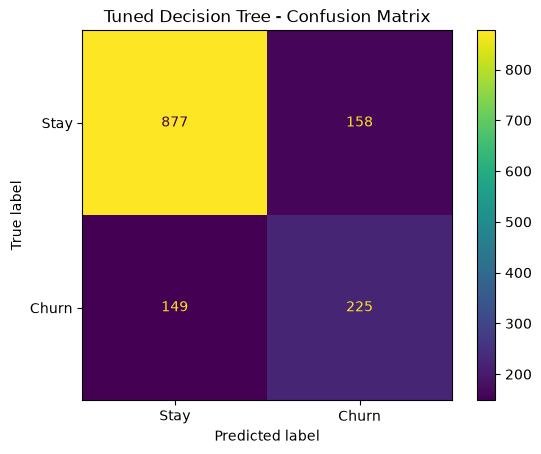

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay


# Train best model on training data

best_tree.fit(
    X_train,
    y_train
)


# Predictions on validation/test set
y_pred = best_tree.predict(
    X_test
)


cm = confusion_matrix(
    y_test,
    y_pred
)


print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Stay",
        "Churn"
    ]
)


disp.plot()

plt.title(
    "Tuned Decision Tree - Confusion Matrix"
)

plt.show()

In [33]:
# Final tuned Decision Tree test metrics

test_probabilities = best_tree.predict_proba(
    X_test
)[:,1]


test_accuracy = accuracy_score(
    y_test,
    y_pred
)

test_precision = precision_score(
    y_test,
    y_pred
)

test_recall = recall_score(
    y_test,
    y_pred
)

test_f1 = f1_score(
    y_test,
    y_pred
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)


test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Test Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})


test_results

,Metric,Test Score
0,Accuracy,0.782115
1,Precision,0.587467
2,Recall,0.601604
3,F1-score,0.594452
4,ROC-AUC,0.829786


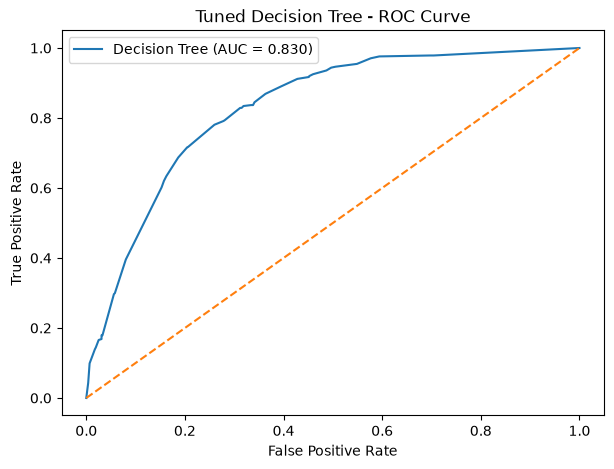

In [34]:
# ROC Curve for Tuned Decision Tree

fpr, tpr, thresholds = roc_curve(
    y_test,
    test_probabilities
)

roc_auc_value = auc(
    fpr,
    tpr
)


plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC = {roc_auc_value:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Tuned Decision Tree - ROC Curve"
)

plt.legend()

plt.show()

In [35]:
plt.show()

In [36]:
plt.savefig(
    "../figures/member2_decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [37]:
plt.show()

In [38]:
plt.savefig(
    "../figures/member2_decision_tree_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [39]:
# Save CV results

cv_summary.to_csv(
    "../outputs/member2_decision_tree_baseline_cv_results.csv",
    index=False
)


tuned_summary.to_csv(
    "../outputs/member2_decision_tree_tuned_cv_results.csv",
    index=False
)


test_results.to_csv(
    "../outputs/member2_decision_tree_test_results.csv",
    index=False
)


print("Results saved successfully")

Results saved successfully


In [40]:
# Save final tuned Decision Tree model

joblib.dump(
    best_tree,
    "../models/decision_tree_model.joblib"
)

print("Decision Tree model saved successfully")

Decision Tree model saved successfully
